✅ YOLO ONNX caricato
✅ Foundry GPT-4o configurato
🚀 Avvio analisi su data/test/images/105_JPG_jpg.rf.5708a5ef86ade6c986f877fabdb267bd.jpg...

SAFETY ANALYSIS REPORT
[YOLO11-ONNX] 4 detections (Person(0.85), Glove(0.81), Helmet(0.80), Glove(0.79)) in 861.7ms
[Foundry-GPT4o] 7 detections (person(0.99), helmet(0.95), glove(0.98), glove(0.98), no_vest(0.90), no_boot(0.85), no_boot(0.85)) in 12604.5ms | 3 VIOLATION(S) FOUND: ['no_vest', 'no_boot', 'no_boot']
  ⚠️  no_vest (conf=0.90)
  ⚠️  no_boot (conf=0.85)
  ⚠️  no_boot (conf=0.85)



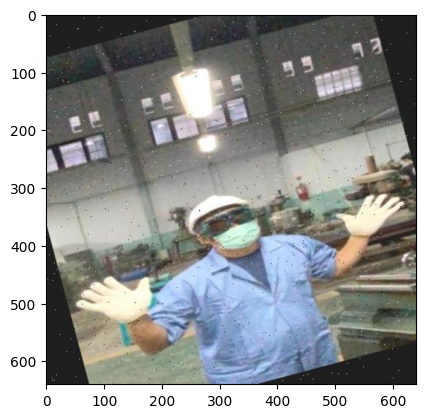

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
from src.visual_security.analyzer import YOLOAnalyzer, FoundryGPT4oAnalyzer, SafetyAnalyzerPipeline
from matplotlib import pyplot as plt

load_dotenv()

YOLO_WEIGHTS = "weights/dataset_1/yolo_nano_640/best.onnx"

analyzers = []

# 1. YOLO locale (richiede training completato)
if Path(YOLO_WEIGHTS).exists():
    analyzers.append(YOLOAnalyzer(model_path=YOLO_WEIGHTS))
    print("✅ YOLO ONNX caricato")
else:
    print(f"⚠️  YOLO ONNX non trovato in {YOLO_WEIGHTS}, skip.")

# 2. Foundry GPT-4o (richiede AZURE_OPENAI_KEY in .env)
if os.getenv("AZURE_OPENAI_KEY"):
    analyzers.append(FoundryGPT4oAnalyzer(api_key=os.getenv("AZURE_OPENAI_KEY"), endpoint=os.getenv("AZURE_OPENAI_URL")))
    print("✅ Foundry GPT-4o configurato")
else:
    print("⚠️  AZURE_OPENAI_KEY non impostato, skip.")

# Esegui l'analisi
TEST_IMAGE = "data/test/images/105_JPG_jpg.rf.5708a5ef86ade6c986f877fabdb267bd.jpg"
pipeline = SafetyAnalyzerPipeline(analyzers)

if Path(TEST_IMAGE).exists():
    print(f"🚀 Avvio analisi su {TEST_IMAGE}...")
    plt.imshow(plt.imread(TEST_IMAGE))
    results = pipeline.run(TEST_IMAGE)
    pipeline.print_report(results)
else:
    print(f"⚠️  Immagine non trovata: {TEST_IMAGE}")
    print("   Modifica TEST_IMAGE con il path corretto.")


In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
import cv2 as cv
from matplotlib import pyplot as plt
import numpy as np
from src.visual_security.analyzer import YOLOAnalyzer, Florence2Analyzer, MoondreamAnalyzer, SafetyHybridPipeline

load_dotenv()

YOLO_WEIGHTS = "weights/dataset_1/yolo_nano_640/best.onnx"
TEST_IMAGE = "data/test/images/105_JPG_jpg.rf.5708a5ef86ade6c986f877fabdb267bd.jpg"

yolo = YOLOAnalyzer(model_path=YOLO_WEIGHTS)
florence = Florence2Analyzer(model_id="microsoft/Florence-2-base", device="cpu")
moondream = MoondreamAnalyzer(device="cpu")  # o "cuda" se hai una GPU
hybrid_pipeline = SafetyHybridPipeline(primary_yolo=yolo, validator_vlm=moondream)

if Path(TEST_IMAGE).exists():
    print(f"🚀 Avvio Analisi Ibrida su: {TEST_IMAGE}")
    img_original = cv.imread(TEST_IMAGE)
    rows, cols = img_original.shape[:2]

    for i in range(12):
        tx = -(i * 5)
        M = np.float32([[1, 0, tx], [0, 1, 0]])
        img_shifted = cv.warpAffine(img_original, M, (cols, rows))

        TEMP_SHIFTED_PATH = "temp_shifted.jpg"
        cv.imwrite(TEMP_SHIFTED_PATH, img_shifted)

        result = hybrid_pipeline.analyze_frame(TEMP_SHIFTED_PATH)

        if result["status"] == "ALERT":
            print(f"⚠️  ALLERTA CONFERMATA al frame {i} (Shift: {tx}px): {result['validated_violations']}")
            plt.imshow(cv.cvtColor(img_shifted, cv.COLOR_BGR2RGB))
            plt.title(f"Alert at frame {i}")
            plt.show()
            break
        else:
            print(f"[{i}] Analisi... Shift: {tx}px | Status: {result['status']}")

# Pulizia
# if os.path.exists(TEMP_SHIFTED_PATH):
#     os.remove(TEMP_SHIFTED_PATH)

🚀 Avvio Analisi Ibrida su: data/test/images/105_JPG_jpg.rf.5708a5ef86ade6c986f877fabdb267bd.jpg
[DEBUG] YOLO ha trovato: ['Person', 'Glove', 'Helmet', 'Glove']
[DEBUG] Violazioni identificate: []
[0] Analisi... Shift: 0px | Status: SAFE
[DEBUG] YOLO ha trovato: ['Person', 'Glove', 'Helmet', 'Glove']
[DEBUG] Violazioni identificate: []
[1] Analisi... Shift: -5px | Status: SAFE
[DEBUG] YOLO ha trovato: ['Glove', 'Person', 'Helmet', 'Glove']
[DEBUG] Violazioni identificate: []
[2] Analisi... Shift: -10px | Status: SAFE
[DEBUG] YOLO ha trovato: ['Person', 'Glove', 'Helmet', 'Glove']
[DEBUG] Violazioni identificate: []
[3] Analisi... Shift: -15px | Status: SAFE
[DEBUG] YOLO ha trovato: ['Person', 'Glove', 'Helmet', 'Glove']
[DEBUG] Violazioni identificate: []
[4] Analisi... Shift: -20px | Status: SAFE
[DEBUG] YOLO ha trovato: ['Glove', 'Person', 'Helmet', 'Glove']
[DEBUG] Violazioni identificate: []
[5] Analisi... Shift: -25px | Status: SAFE
[DEBUG] YOLO ha trovato: ['Person', 'Glove', 'Hel